# Testando Perceptron com o Dataset Iris

O dataset Iris (hello world) em Machine Learning, contém medições de 3 espécies de flores (Setosa, Versicolor e Virginica). 

Como o nosso Perceptron é um classificador estritamente binário (só consegue prever duas classes: 0 ou 1), vamos adaptar o problema para classificar apenas duas espécies que são linearmente separáveis. Além disso, usaremos apenas duas características (comprimento e largura da pétala) para que possamos visualizar a fronteira de decisão em um gráfico 2D.

## Dependências e Configurações

In [50]:
from perceptron import Perceptron 

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

print(' - Bibliotecas carregadas com sucesso - ')

 - Bibliotecas carregadas com sucesso - 


## 1. Carregando Dados

In [25]:
iris = load_iris()
X = iris.data
y = iris.target

print('Classes  :', iris.target_names)
print('Features :', iris.feature_names)

Classes  : ['setosa' 'versicolor' 'virginica']
Features : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [26]:
X[:5], y[:5]

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2]]),
 array([0, 0, 0, 0, 0]))

## 2. Preprocessamento

### 2.1 filtragem de dados binários
O Perceptron original só funciona para 2 classes. Vamos selecionar apenas as classes Setosa (0) e Versicolor (1). Também vamos selecionar apenas as colunas referentes ao comprimento e largura da pétala (índices 2 e 3).

In [27]:
X[y<2][:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [28]:
y[y<2][:5]

array([0, 0, 0, 0, 0])

In [29]:
X[:,[2,3]][:5]

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2]])

In [40]:
#selecionando registros onde a classe é 0 ou 1 :: setosa - versicolor
mask = y < 2
X = X[mask]
y = y[mask]

#selecionando apenas as features da petala :: indices 2 e 3
X = X[:, [2, 3]]

print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print(f"Classes únicas em y: {np.unique(y)}")

Formato de X: (100, 2)
Formato de y: (100,)
Classes únicas em y: [0 1]


### 2.2 Normalização 

In [42]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X[:5]

array([[-1.01297765, -1.04211089],
       [-1.01297765, -1.04211089],
       [-1.08231219, -1.04211089],
       [-0.94364311, -1.04211089],
       [-1.01297765, -1.04211089]])

In [43]:
print(f'Formato de X: {X.shape}')

Formato de X: (100, 2)


### 2.3 Divisão bases

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80, 2), (20, 2), (80,), (20,))

## 3. Análise Exploratória (Scatter Plot)

Antes de treinar o modelo, vamos visualizar os dados. Esperamos ver dois grupos claramente separáveis, o que garante que o Perceptron convergirá.

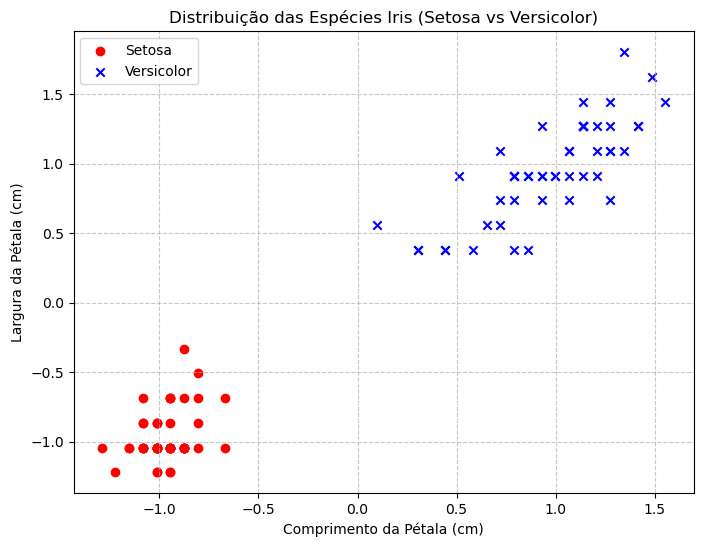

In [45]:
plt.figure(figsize=(8, 6))

plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', marker='o', label='Setosa')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='x', label='Versicolor')

plt.xlabel('Comprimento da Pétala (cm)')
plt.ylabel('Largura da Pétala (cm)')
plt.title('Distribuição das Espécies Iris (Setosa vs Versicolor)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 4. Treinamento do Modelo

Agora instanciar o Perceptron e treiná-lo, e com o verbose para ver o progresso.

In [46]:
#instanciando o modelo
modelo_iris = Perceptron(
    learning_rate=0.1, 
    epochs=50, 
    verbose=True, 
    log_every=1, 
    random_state=42
)

#treinando o modelo
modelo_iris.fit(X_train, y_train)

Época:    1/50   | Erros:   2 | Acurácia: 100.00% | Bias:   0.0000
Época:    2/50   | Erros:   0 | Acurácia: 100.00% | Bias:   0.0000

Convergência alcançada na época 2.


## 5. Avaliação e Curva de Aprendizado

Agora é verificar a acurácia final usando o método score e plotar como os erros e a acurácia evoluíram ao longo das épocas.

In [48]:
#acuracia final
acuracia_treino = modelo_iris.score(X_train, y_train)
acuracia_teste  = modelo_iris.score(X_test, y_test)

print(f"Acurácia do modelo no Treino: {acuracia_treino:.2%}")
print(f"Acurácia do modelo no Teste : {acuracia_teste:.2%}")

Acurácia do modelo no Treino: 100.00%
Acurácia do modelo no Teste : 100.00%


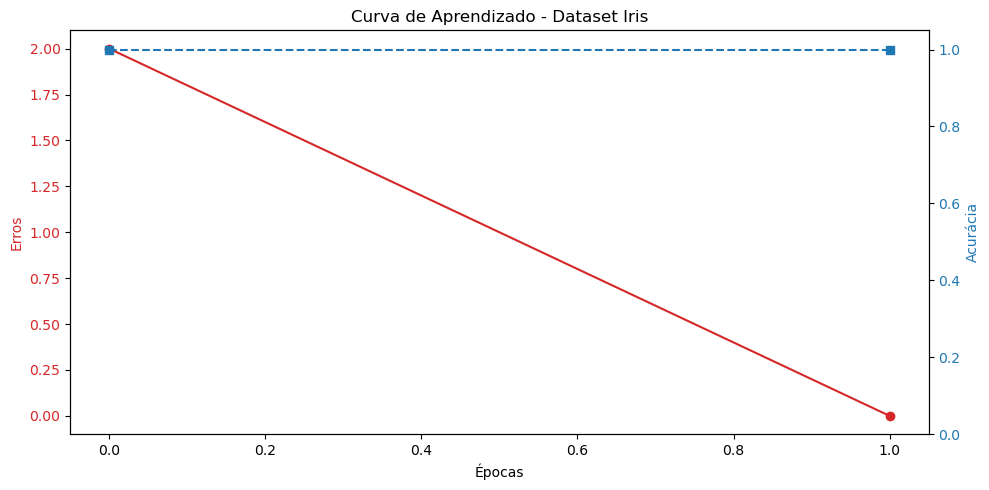

In [49]:
#plote da curva de aprendizado
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Erros', color=color)
ax1.plot(modelo_iris.errors, color=color, marker='o', label='Erros')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Acurácia', color=color)  
ax2.plot(modelo_iris.accuracy_history, color=color, marker='s', linestyle='--', label='Acurácia')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 1.05)

plt.title('Curva de Aprendizado - Dataset Iris')
fig.tight_layout()  
plt.show()

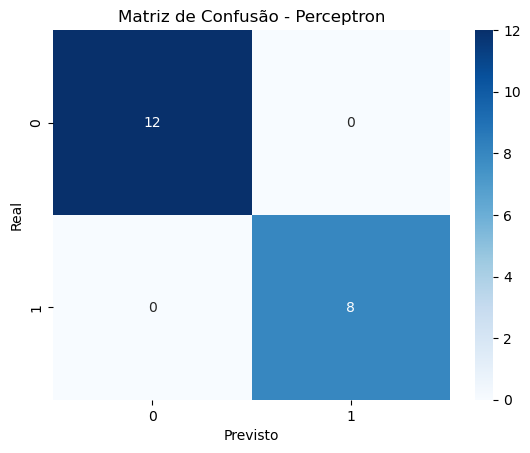

In [51]:
#matriz de confusao
y_pred = modelo_iris.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão - Perceptron")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

In [53]:
#relatorio
print(classification_report(y_test, y_pred) )

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

